# Optional Lab: Multi-class Classification with Softmax Regression (From Scratch)

## Goals
In this lab you will:
- Extend logistic regression from two classes to any number of classes using the softmax function
- Implement softmax regression manually with NumPy — no `sklearn.linear_model` shortcuts
- Train the model with gradient descent and visualize how it separates the classes

## Tools
In this lab we will make use of:
- NumPy, for the model, the math, and the gradient descent loop
- Matplotlib, for plotting the data and the decision regions
- scikit-learn, only to generate a toy dataset and, at the very end, to sanity-check our from-scratch result

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_blobs

np.random.seed(42)
plt.rcParams['figure.figsize'] = (7, 5)

## Problem Statement

Let's pick up the story from class: predicting a student's outcome — **Fail**, **Pass**, or **Distinction** — from two continuous scores, an assignment score and an exam score (both out of 100).

Unlike the pass/fail lab, there are now **three** possible outcomes instead of two. This is exactly the situation that motivated softmax: sigmoid gives one probability, but here we need three numbers that describe how the model splits its confidence across three doors, and those three numbers need to add up to 1.

We'll generate a small synthetic dataset so the boundaries are easy to see, then implement softmax regression completely by hand.

In [2]:
# Three classes: 0 = Fail, 1 = Pass, 2 = Distinction
class_names = ['Fail', 'Pass', 'Distinction']

X, y = make_blobs(
    n_samples=300,
    centers=[[35, 40], [65, 60], [85, 88]],
    cluster_std=[10, 9, 7],
    random_state=42
)
X = np.clip(X, 0, 100)   # keep scores in a sensible 0-100 range

m = X.shape[0]
print(f"Number of training examples (m): {m}")
print(f"Number of features (n): {X.shape[1]}")
print(f"Classes: {class_names}")

Number of training examples (m): 300
Number of features (n): 2
Classes: ['Fail', 'Pass', 'Distinction']


### Visualizing the data

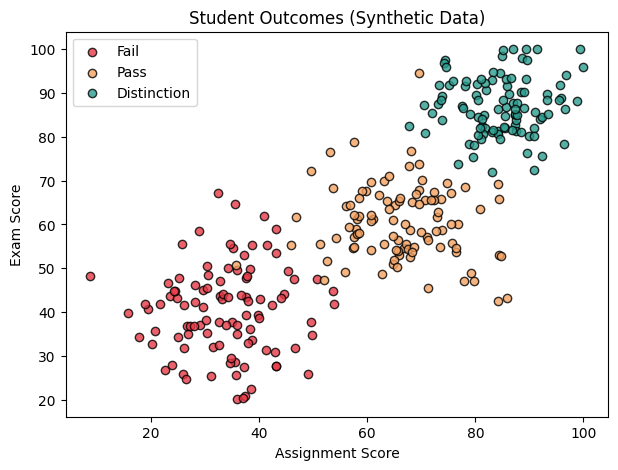

In [3]:
colors = ['#e63946', '#f4a261', '#2a9d8f']

plt.figure()
for cls in range(3):
    plt.scatter(X[y == cls, 0], X[y == cls, 1],
                c=colors[cls], label=class_names[cls],
                edgecolor='k', alpha=0.8)
plt.xlabel('Assignment Score')
plt.ylabel('Exam Score')
plt.title('Student Outcomes (Synthetic Data)')
plt.legend()
plt.show()

## From One Label to One-Hot

The label `y` currently stores a single integer per student — `0`, `1`, or `2`. To compute a loss that checks "how much probability did the model give the **true** class," it's easiest if the true answer is also written as a vector of the same shape as the model's output.

| Student's true label | One-hot vector |
|:---|:---|
| Fail (0) | [1, 0, 0] |
| Pass (1) | [0, 1, 0] |
| Distinction (2) | [0, 0, 1] |

This is exactly the "switch" idea from binary logistic regression — just with three positions instead of two.

In [4]:
def one_hot_encode(y, num_classes):
    """
    Converts integer class labels into one-hot vectors.

    Args:
      y (ndarray (m,))   : integer class labels, values in [0, num_classes)
      num_classes (int)  : total number of classes K

    Returns:
      Y (ndarray (m, num_classes)): one-hot encoded labels
    """
    m = y.shape[0]
    Y = np.zeros((m, num_classes))
    for i in range(m):
        Y[i, y[i]] = 1
    return Y

In [5]:
Y_onehot = one_hot_encode(y, num_classes=3)

print("First 5 integer labels:")
print(y[:5])
print("\nFirst 5 one-hot rows:")
print(Y_onehot[:5])

First 5 integer labels:
[0 0 2 1 0]

First 5 one-hot rows:
[[1. 0. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]]


## The Softmax Function

Softmax turns a row of raw scores (logits) — one per class — into a row of probabilities that sum to 1:

$$ \text{softmax}(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}} $$

Think of it as a **confidence pie**: every class gets a slice, the biggest raw score always gets the biggest slice, and the slices always add up to a whole pie.

> **Note**: In practice we subtract the maximum logit from every logit before exponentiating. This does not change the result mathematically — the shift cancels out in the division — but it keeps `np.exp` from overflowing when a logit is a large number.

In [6]:
def softmax(Z):
    """
    Computes the softmax of each row of Z.

    Args:
      Z (ndarray (m, k)): raw scores (logits) for m examples and k classes

    Returns:
      P (ndarray (m, k)): softmax probabilities — each row sums to 1
    """
    Z_shifted = Z - np.max(Z, axis=1, keepdims=True)   # numerical stability
    exp_Z = np.exp(Z_shifted)
    P = exp_Z / np.sum(exp_Z, axis=1, keepdims=True)
    return P

Quick sanity check with the same numbers from class — logits of `Fail = 1.0`, `Pass = 2.0`, `Distinction = 0.5`:

In [7]:
toy_logits = np.array([[1.0, 2.0, 0.5]])
toy_probs = softmax(toy_logits)

print(f"Logits:                {toy_logits[0]}")
print(f"Softmax probabilities: {np.round(toy_probs[0], 3)}")
print(f"Sum of probabilities:  {toy_probs.sum():.3f}")

Logits:                [1.  2.  0.5]
Softmax probabilities: [0.231 0.629 0.14 ]
Sum of probabilities:  1.000


## The Model: From Features to Logits

Just like `z = wx + b` in plain logistic regression, we need a logit for *each* class. Instead of a single weight vector `w`, softmax regression uses a weight **matrix** `W` — one column per class — plus a bias for each class:

$$ Z = XW + b $$

- `X` has shape `(m, n)` — `m` students, `n` features
- `W` has shape `(n, k)` — `n` features, `k` classes
- `b` has shape `(k,)` — one bias per class
- `Z` has shape `(m, k)` — one logit per student, per class

Feeding `Z` through `softmax()` gives `P`, the `(m, k)` matrix of predicted probabilities.

## Cost Function: Cross-Entropy Loss

For one example, the loss only looks at the probability the model assigned to the **true** class:

$$ \text{loss} = -\log(p_{\text{true class}}) $$

Because the true label is one-hot, this can be written as a sum over all classes where only the true-class term survives — the same "switch" trick from the binary case:

$$ J(W,b) = -\frac{1}{m}\sum_{i=1}^{m}\sum_{k=1}^{K} y^{(i)}_k \log\!\left(p^{(i)}_k\right) $$

The code below computes it by looping over each example, in the same style as the cost function from the linear regression lab — the loop makes it obvious that we're just scoring one student at a time and averaging.

In [8]:
def compute_cost(X, Y_onehot, W, b):
    """
    Computes the cross-entropy cost for softmax regression.

    Args:
      X (ndarray (m, n))        : input features
      Y_onehot (ndarray (m, k)) : one-hot encoded true labels
      W (ndarray (n, k))        : weights
      b (ndarray (k,))          : biases

    Returns:
      cost (float): the average cross-entropy cost over all m examples
    """
    m = X.shape[0]
    Z = X @ W + b
    P = softmax(Z)

    cost_sum = 0
    for i in range(m):
        true_class = np.argmax(Y_onehot[i])
        cost_sum += -np.log(P[i, true_class] + 1e-15)   # tiny epsilon avoids log(0)

    cost = cost_sum / m
    return cost

## Gradients

The gradient of the cross-entropy cost with respect to the logits has a famously clean form: it's just `P - Y` — the difference between what the model predicted and the true one-hot answer. From there:

$$ \frac{\partial J}{\partial W} = \frac{1}{m} X^T (P - Y) \qquad\qquad \frac{\partial J}{\partial b} = \frac{1}{m}\sum_{i=1}^{m}\left(P^{(i)} - Y^{(i)}\right) $$

You don't need to re-derive this by hand to use it — just notice the shape. It looks exactly like the gradient from plain linear and logistic regression, just with matrices standing in for vectors.

In [9]:
def compute_gradients(X, Y_onehot, W, b):
    """
    Computes the gradients of the cost function with respect to W and b.

    Args:
      X (ndarray (m, n))        : input features
      Y_onehot (ndarray (m, k)) : one-hot encoded true labels
      W (ndarray (n, k))        : weights
      b (ndarray (k,))          : biases

    Returns:
      dW (ndarray (n, k)): gradient of cost with respect to W
      db (ndarray (k,))  : gradient of cost with respect to b
    """
    m = X.shape[0]
    Z = X @ W + b
    P = softmax(Z)

    error = P - Y_onehot            # (m, k)
    dW = (X.T @ error) / m          # (n, k)
    db = np.sum(error, axis=0) / m  # (k,)

    return dW, db

## Training with Gradient Descent

Same loop as every model this course has built: guess, measure how wrong, step downhill, repeat.

In [10]:
def train(X, y, num_classes, learning_rate=0.1, num_iterations=1000, print_every=100):
    """
    Trains a softmax regression model using batch gradient descent.

    Args:
      X (ndarray (m, n))    : input features
      y (ndarray (m,))      : integer class labels
      num_classes (int)     : number of classes K
      learning_rate (float) : gradient descent step size
      num_iterations (int)  : number of gradient descent steps
      print_every (int)     : how often to print the cost

    Returns:
      W (ndarray (n, k))   : learned weights
      b (ndarray (k,))     : learned biases
      cost_history (list)  : cost recorded at every iteration
    """
    m, n = X.shape
    Y_onehot = one_hot_encode(y, num_classes)

    W = np.zeros((n, num_classes))
    b = np.zeros(num_classes)
    cost_history = []

    for i in range(num_iterations):
        dW, db = compute_gradients(X, Y_onehot, W, b)
        W = W - learning_rate * dW
        b = b - learning_rate * db

        cost = compute_cost(X, Y_onehot, W, b)
        cost_history.append(cost)

        if i % print_every == 0 or i == num_iterations - 1:
            print(f"Iteration {i:4d}: cost = {cost:.4f}")

    return W, b, cost_history

### A quick but important detail: feature scaling

The assignment and exam scores both range roughly from 0 to 100, but gradient descent converges far more smoothly when features are on a similar, small scale — the same lesson from feature scaling in linear regression applies here too.

In [11]:
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_scaled = (X - X_mean) / X_std

print(f"Feature means before scaling: {X.mean(axis=0).round(2)}")
print(f"Feature means after scaling:  {X_scaled.mean(axis=0).round(6)}")

Feature means before scaling: [61.54 62.59]
Feature means after scaling:  [-0.  0.]


In [12]:
W, b, cost_history = train(
    X_scaled, y,
    num_classes=3,
    learning_rate=0.5,
    num_iterations=1000,
    print_every=100
)

Iteration    0: cost = 0.8569
Iteration  100: cost = 0.1709
Iteration  200: cost = 0.1287
Iteration  300: cost = 0.1117
Iteration  400: cost = 0.1024
Iteration  500: cost = 0.0965
Iteration  600: cost = 0.0924
Iteration  700: cost = 0.0894
Iteration  800: cost = 0.0870
Iteration  900: cost = 0.0852
Iteration  999: cost = 0.0838


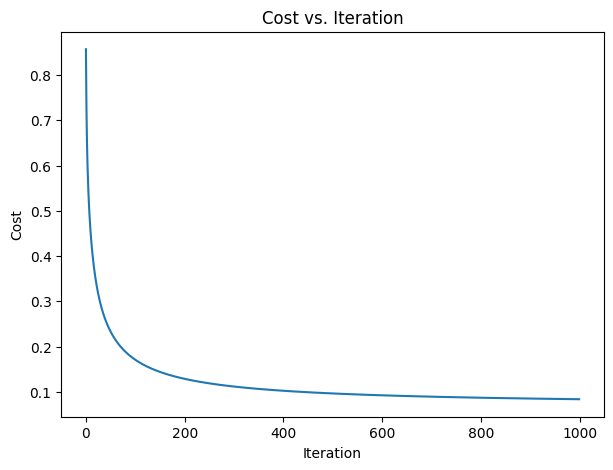

In [13]:
plt.figure()
plt.plot(cost_history)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Cost vs. Iteration')
plt.show()

## Making Predictions: Argmax

The model outputs three probabilities per student. To turn that into an actual prediction, we don't pick a threshold like we did with sigmoid — we just point at the biggest slice.

In [14]:
def predict(X, W, b):
    """
    Predicts the class with the highest probability for each example.

    Args:
      X (ndarray (m, n)) : input features
      W (ndarray (n, k)) : learned weights
      b (ndarray (k,))   : learned biases

    Returns:
      predictions (ndarray (m,)): predicted class index for each example
    """
    Z = X @ W + b
    P = softmax(Z)
    predictions = np.argmax(P, axis=1)
    return predictions

predictions = predict(X_scaled, W, b)
accuracy = np.mean(predictions == y)
print(f"Training accuracy: {accuracy * 100:.2f}%")

Training accuracy: 98.00%


## Visualizing the Decision Regions

This is the picture that matters most for multi-class classification: not a single line, but three regions splitting up the plane, one per class.

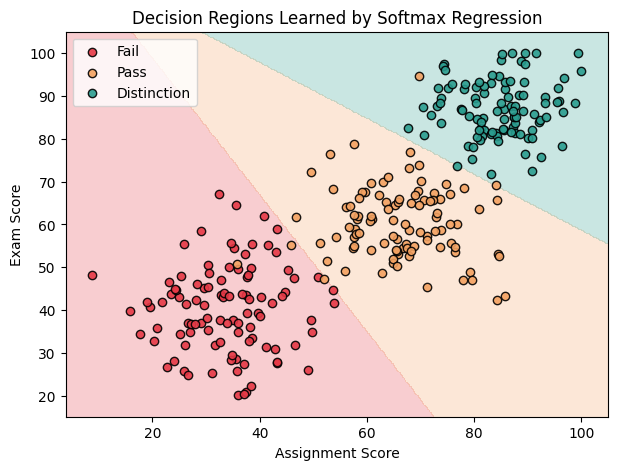

In [15]:
def plot_decision_regions(X_raw, y, W, b, X_mean, X_std, class_names, colors):
    x_min, x_max = X_raw[:, 0].min() - 5, X_raw[:, 0].max() + 5
    y_min, y_max = X_raw[:, 1].min() - 5, X_raw[:, 1].max() + 5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_scaled = (grid - X_mean) / X_std

    Z = predict(grid_scaled, W, b).reshape(xx.shape)

    background_cmap = ListedColormap([c + '40' for c in colors])   # translucent fill

    plt.figure()
    plt.contourf(xx, yy, Z, levels=[-0.5, 0.5, 1.5, 2.5], cmap=background_cmap)
    for cls in range(3):
        plt.scatter(X_raw[y == cls, 0], X_raw[y == cls, 1],
                    c=colors[cls], label=class_names[cls],
                    edgecolor='k', alpha=0.9)
    plt.xlabel('Assignment Score')
    plt.ylabel('Exam Score')
    plt.title('Decision Regions Learned by Softmax Regression')
    plt.legend()
    plt.show()

plot_decision_regions(X, y, W, b, X_mean, X_std, class_names, colors)

### Challenge

Try adjusting `learning_rate` and `num_iterations` in the training cell above, then re-run the training, cost-plot, and decision-region cells. What happens to the cost curve if the learning rate is too high? Too low?

<details>
<summary>
    <font size='3' color='darkgreen'><b>Hints</b></font>
</summary>
    <p>
    <ul>
        <li>A learning rate that's too high often makes the cost bounce around or increase instead of decreasing smoothly.</li>
        <li>A learning rate that's too low will still converge — it will just take many more iterations to get there.</li>
    </ul>
    </p>
</details>

## Sanity Check: Comparing with scikit-learn

Before wrapping up, let's confirm the from-scratch implementation agrees with a trusted library. This isn't cheating — it's exactly how you'd debug a from-scratch implementation in practice.

In [16]:
from sklearn.linear_model import LogisticRegression

sklearn_model = LogisticRegression(max_iter=1000)
sklearn_model.fit(X_scaled, y)
sklearn_accuracy = sklearn_model.score(X_scaled, y)

print(f"Our from-scratch accuracy : {accuracy * 100:.2f}%")
print(f"scikit-learn accuracy     : {sklearn_accuracy * 100:.2f}%")

Our from-scratch accuracy : 98.00%
scikit-learn accuracy     : 98.33%


## Congratulations!

In this lab you have learned:
- Softmax regression extends logistic regression from two classes to any number of classes K
- One-hot encoding turns a class label into a vector, so the loss can be computed the same way for every class
- Cross-entropy cost is the same idea as log loss, just aimed at whichever slice of the pie corresponds to the true class
- The gradient has the same clean shape as ordinary logistic regression — just `P - Y` averaged over the training set
- The decision boundary is no longer a single line but a set of regions, one per class